# Music Diffusion Transformer

## Dataset

The [Song Describer Dataset (SDD)](https://zenodo.org/records/10072001) is a multimodal music-language dataset designed for tasks such as music captioning, text-to-music generation, and music-language retrieval. It contains approximately 1,100 human-written natural language captions paired with 706 permissively licensed music recordings, covering a wide range of musical styles, instruments, moods, and production characteristics. The dataset was introduced by researchers from institutions including Queen Mary University of London and Universitat Pompeu Fabra as a public benchmark for evaluating music-and-language models. Unlike many proprietary music datasets, SDD emphasizes open accessibility and standardized evaluation for cross-modal learning research. It is particularly suitable for training and benchmarking Transformer-, diffusion-, and CLAP-based architectures for text-conditioned music generation and retrieval tasks

In [1]:
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
import librosa
import torch
import os


class AudioDataset(Dataset):
    def __init__(self, csv_path="./dataset/song_describer.csv", audio_dir="./dataset/audio/"):
        self.df = pd.read_csv(csv_path)
        self.audio_dir = audio_dir
        self.SAMPLE_RATE = 22050
        self.N_MELS = 80
        self.N_FFT = 1024
        self.HOP_LENGTH = 256
        self.WIN_LENGTH = 1024
        self.max_len = self.SAMPLE_RATE * 10
        self.generate_file_map()

    def __len__(self):
        return len(self.df)

    def generate_file_map(self):
        self.file_map = {}

        for root, dirs, files in os.walk(self.audio_dir):
            for f in files:
                if f.endswith(".mp3"):
                    track_id = f.split(".")[0]
                    self.file_map[track_id] = os.path.join(root, f)
    
    def load_audio(self, path, target_sr=22050):
        wav, sr = librosa.load(path, sr=target_sr, mono=True)

        if len(wav) > self.max_len:
            wav = wav[:self.max_len]
        else:
            wav = np.pad(wav, (0, self.max_len - len(wav)))
        return wav

    def audio_to_mel(self, audio_path):
        wav = self.load_audio(audio_path, self.SAMPLE_RATE)
    
        mel = librosa.feature.melspectrogram(
            y=wav,
            sr=self.SAMPLE_RATE,
            n_fft=self.N_FFT,
            hop_length=self.HOP_LENGTH,
            win_length=self.WIN_LENGTH,
            n_mels=self.N_MELS,
            fmin=0,
            fmax=8000,
            power=1.0
        )
    
        mel = np.log(np.maximum(mel, 1e-5))
    
        # roughly normalize for diffusion
        mel = np.clip(mel, -11.5, 2.0)
        mel_norm = (mel + 11.5) / 13.5 * 2 - 1
    
        return torch.tensor(mel_norm, dtype=torch.float32).unsqueeze(0)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        caption = row["caption"]
        track_id = str(row["track_id"])

        mel_spectrum = self.audio_to_mel(self.file_map[track_id])
        return mel_spectrum, caption


def denorm_for_bigvgan(mel_norm):
    mel = mel_norm.clamp(-1, 1)
    mel = (mel + 1) / 2 * 13.5 - 11.5
    return mel

D:\Softwares\minconda3\envs\llm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


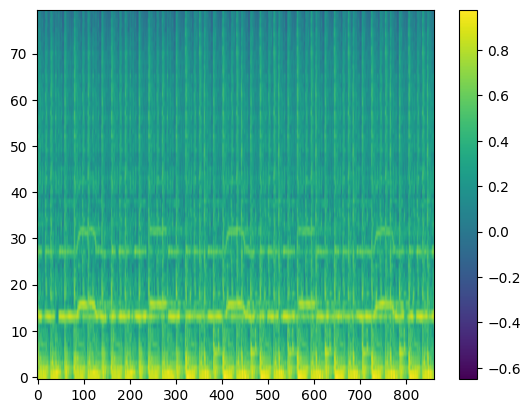

In [2]:
import matplotlib.pyplot as plt

audio_dataset = AudioDataset()

mel_np = audio_dataset[0][0].squeeze(0).detach().cpu().numpy()
plt.imshow(mel_np, origin="lower", aspect="auto")
plt.colorbar()

## Model Architectures

### CLAP Text Encoder

The CLAP Text Encoder is used to convert a natural language music prompt into a fixed-dimensional conditioning embedding. It uses a pretrained CLAP model, which has learned an aligned representation space between text and audio. Given an input caption, the processor first tokenizes the text and creates the attention mask, then the CLAP text encoder extracts a semantic text feature. This feature is L2-normalized and passed through a projection layer so that its dimension matches the diffusion model’s conditioning input. During training, the CLAP model is frozen, and only the downstream diffusion model learns how to use the text embedding to guide mel-spectrogram generation.

In [3]:
from transformers import ClapModel, ClapProcessor
import torch
import torch.nn as nn

class CLAPTextEncoder(nn.Module):
    def __init__(self, model_name="laion/clap-htsat-fused", out_dim=512):
        super().__init__()
        self.processor = ClapProcessor.from_pretrained(model_name)
        self.clap = ClapModel.from_pretrained(model_name)

        for p in self.clap.parameters():
            p.requires_grad = False

        self.proj = nn.Linear(768, out_dim)

    def forward(self, prompts):
        device = next(self.clap.parameters()).device

        inputs = self.processor(
            text=prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad():
            outputs = self.clap.text_model(**inputs)
            token_emb = outputs.last_hidden_state

        token_emb = self.proj(token_emb)

        return token_emb

D:\Softwares\minconda3\envs\llm\Lib\site-packages\transformers\integrations\sonicmoe.py:99: FutureWarning: torch._dynamo.allow_in_graph is deprecated and will be removed in a future version. Use torch._dynamo.nonstrict_trace instead.
  @torch._dynamo.allow_in_graph
D:\Softwares\minconda3\envs\llm\Lib\site-packages\torch\compiler\__init__.py:148: FutureWarning: torch._dynamo.allow_in_graph is deprecated and will be removed in a future version. Use torch._dynamo.nonstrict_trace instead.
  return torch._dynamo.allow_in_graph(fn)


In [4]:
text_encoder = CLAPTextEncoder(out_dim=512).cuda()

prompts = [
    "playful cartoon comedy music",
    "chaotic banana-themed soundtrack"
]

cond = text_encoder(prompts)
print(cond.shape)

Loading weights: 100%|█████████████████████████████████████████████████████████████████████| 477/477 [00:00<00:00, 8511.12it/s]


torch.Size([2, 8, 512])


### Diffusion Model

In [5]:
class NoiseScheduler:
    def __init__(self, num_steps=1000, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.num_steps = num_steps
        self.device = device

        self.betas = torch.linspace(beta_start, beta_end, num_steps).to(device)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, x0, noise, t):
        alpha_bar = self.alpha_bars[t].view(-1, 1, 1, 1)
        return torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * noise

    @torch.no_grad()
    def step(self, x_t, pred_noise, t):
        beta_t = self.betas[t]
        alpha_t = self.alphas[t]
        alpha_bar_t = self.alpha_bars[t]

        beta_t = beta_t.view(-1, 1, 1, 1)
        alpha_t = alpha_t.view(-1, 1, 1, 1)
        alpha_bar_t = alpha_bar_t.view(-1, 1, 1, 1)

        mean = (1 / torch.sqrt(alpha_t)) * (
            x_t - (beta_t / torch.sqrt(1 - alpha_bar_t)) * pred_noise
        )

        noise = torch.randn_like(x_t)

        mask = (t > 0).float().view(-1, 1, 1, 1)

        return mean + mask * torch.sqrt(beta_t) * noise


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_ch)

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)

    def forward(self, x, temb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        h = h + self.time_proj(temb).view(-1, h.shape[1], 1, 1)

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)

        return h + self.skip(x)


class CrossAttentionBlock(nn.Module):
    def __init__(self, dim, cond_dim=512, num_heads=1):
        super().__init__()

        self.norm = nn.LayerNorm(dim)

        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.cond_proj = nn.Linear(cond_dim, dim)

    def forward(self, x, cond):
        # x: [B, C, H, W]
        # cond: [B, text_len, cond_dim]

        B, C, H, W = x.shape

        x_seq = x.flatten(2).transpose(1, 2)   # [B, H*W, C]
        x_norm = self.norm(x_seq)

        cond = self.cond_proj(cond)            # [B, text_len, C]

        attn_out, _ = self.attn(
            query=x_norm,
            key=cond,
            value=cond
        )

        x_seq = x_seq + attn_out

        return x_seq.transpose(1, 2).view(B, C, H, W)


class CrossAttentionBlock(nn.Module):
    def __init__(self, dim, cond_dim=512, num_heads=4):
        super().__init__()

        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.cond_proj = nn.Linear(cond_dim, dim)

    def forward(self, x, cond):
        # x: [B, C, H, W]
        # cond: [B, text_len, cond_dim]

        B, C, H, W = x.shape

        x_seq = x.flatten(2).transpose(1, 2)   # [B, H*W, C]
        x_norm = self.norm(x_seq)

        cond = self.cond_proj(cond)            # [B, text_len, C]

        attn_out, _ = self.attn(
            query=x_norm,
            key=cond,
            value=cond
        )

        x_seq = x_seq + attn_out

        x = x_seq.transpose(1, 2).view(B, C, H, W)

        return x


class CrossAttentionUNet(nn.Module):
    def __init__(self, cond_dim=512, time_dim=128, num_heads=1):
        super().__init__()

        self.time_embed = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # Encoder
        self.down1 = ResBlock(1, 64, time_dim)
        self.pool1 = nn.Conv2d(64, 64, 4, stride=2, padding=1)

        self.down2 = ResBlock(64, 128, time_dim)
        self.pool2 = nn.Conv2d(128, 128, 4, stride=2, padding=1)

        self.down3 = ResBlock(128, 256, time_dim)
        self.pool3 = nn.Conv2d(256, 256, 4, stride=2, padding=1)

        # Bottleneck
        self.mid1 = ResBlock(256, 256, time_dim)
        self.cross_attn = CrossAttentionBlock(
            dim=256,
            cond_dim=cond_dim,
            num_heads=num_heads
        )
        self.mid2 = ResBlock(256, 256, time_dim)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 256, 4, stride=2, padding=1)
        self.dec3 = ResBlock(256 + 256, 128, time_dim)

        self.up2 = nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1)
        self.dec2 = ResBlock(128 + 128, 64, time_dim)

        self.up1 = nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1)
        self.dec1 = ResBlock(64 + 64, 64, time_dim)

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t, cond_tokens):
        # x: [B, 1, 80, T]
        # t: [B]
        # cond_tokens: [B, text_len, 512]

        original_h, original_w = x.shape[2], x.shape[3]

        t = t.float().unsqueeze(-1) / 1000.0
        temb = self.time_embed(t)

        # Encoder
        h1 = self.down1(x, temb)       # [B, 64, H, W]
        p1 = self.pool1(h1)

        h2 = self.down2(p1, temb)      # [B, 128, H/2, W/2]
        p2 = self.pool2(h2)

        h3 = self.down3(p2, temb)      # [B, 256, H/4, W/4]
        p3 = self.pool3(h3)

        # Bottleneck
        h = self.mid1(p3, temb)
        h = self.cross_attn(h, cond_tokens)
        h = self.mid2(h, temb)

        # Decoder + skip connections
        h = self.up3(h)
        h = self.match_size(h, h3)
        h = torch.cat([h, h3], dim=1)
        h = self.dec3(h, temb)

        h = self.up2(h)
        h = self.match_size(h, h2)
        h = torch.cat([h, h2], dim=1)
        h = self.dec2(h, temb)

        h = self.up1(h)
        h = self.match_size(h, h1)
        h = torch.cat([h, h1], dim=1)
        h = self.dec1(h, temb)

        out = self.out(h)

        return out[:, :, :original_h, :original_w]

    def match_size(self, x, ref):
        return F.interpolate(
            x,
            size=ref.shape[2:],
            mode="bilinear",
            align_corners=False
        )

### Training model

In [ ]:
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm


device = "cuda" if torch.cuda.is_available() else "cpu"

clap_encoder = CLAPTextEncoder(out_dim=512).to(device)
clap_encoder.eval()

unet = CrossAttentionUNet(cond_dim=512, num_heads=4).to(device)

scheduler = NoiseScheduler(num_steps=1000, device=device)

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

dataset = AudioDataset(
    csv_path="./dataset/song_describer.csv",
    audio_dir="./dataset/audio/"
)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)


num_epochs = 100

for epoch in range(num_epochs):
    unet.train()
    total_loss = 0

    for mel, caption in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        mel = mel.to(device)

        with torch.no_grad():
            cond_tokens = clap_encoder(caption).to(device)

        noise = torch.randn_like(mel)

        t = torch.randint(
            0,
            scheduler.num_steps,
            (mel.size(0),),
            device=device
        )

        noisy_mel = scheduler.add_noise(mel, noise, t)
        pred_noise = unet(noisy_mel, t, cond_tokens)

        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    unet.eval()
    val_loss = 0

    with torch.no_grad():
        for mel, caption in val_loader:
            mel = mel.to(device)
            cond_tokens = clap_encoder(caption).to(device)

            noise = torch.randn_like(mel)

            t = torch.randint(
                0,
                scheduler.num_steps,
                (mel.size(0),),
                device=device
            )

            noisy_mel = scheduler.add_noise(mel, noise, t)
            pred_noise = unet(noisy_mel, t, cond_tokens)

            loss = F.mse_loss(pred_noise, noise)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train loss: {avg_train_loss:.4f} | "
        f"val loss: {avg_val_loss:.4f}"
    )

    if (epoch + 1) % 5 == 0:
        torch.save({
            "epoch": epoch + 1,
            "unet": unet.state_dict(),
            "optimizer": optimizer.state_dict(),
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
        }, f"checkpoint_epoch_{epoch+1}.pt")

Epoch 1/100:   1%|▌                                                                            | 1/125 [00:02<04:34,  2.21s/it]

In [ ]:
checkpoint = {
    "epoch": 150,
    "model_state_dict": unet.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": loss.item()
}

torch.save(
    checkpoint,
    "checkpoint.pth"
)

### Overfit one batch

In [ ]:
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm


device = "cuda" if torch.cuda.is_available() else "cpu"

clap_encoder = CLAPTextEncoder(out_dim=512).to(device)
clap_encoder.eval()

unet = CrossAttentionUNet(num_heads=4).to(device)

scheduler = NoiseScheduler(num_steps=1000, device=device)

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

dataset = AudioDataset(
    csv_path="./dataset/song_describer.csv",
    audio_dir="./dataset/audio/"
)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)


train_loader = DataLoader(
    train_dataset,
    batch_size=5,
    shuffle=True,
    num_workers=0
)


mel, caption = next(iter(train_loader))

mel = mel.to(device)

with torch.no_grad():
    cond_tokens = clap_encoder(caption).to(device)


losses = []

unet.train()

for step in tqdm(range(10000)):

    noise = torch.randn_like(mel)

    t = torch.randint(
        0,
        scheduler.num_steps,
        (mel.size(0),),
        device=device
    )

    noisy_mel = scheduler.add_noise(
        mel,
        noise,
        t
    )

    pred_noise = unet(
        noisy_mel,
        t,
        cond_tokens
    )

    loss = F.mse_loss(
        pred_noise,
        noise
    )

    optimizer.zero_grad()

    loss.backward()
    torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)

    optimizer.step()

    losses.append(loss.item())

    if step % 50 == 0:
        print(
            step,
            loss.item()
        )

In [10]:
@torch.no_grad()
def sample_mel_ddim(
    unet,
    clap_encoder,
    scheduler,
    prompt,
    mel_shape=(1, 1, 80, 862),
    device="cuda",
    ddim_steps=100,
    eta=0.0
):
    unet.eval()
    clap_encoder.eval()

    cond = clap_encoder([prompt]).to(device)

    x = torch.randn(mel_shape, device=device)

    timesteps = torch.linspace(
        scheduler.num_steps - 1,
        0,
        ddim_steps,
        device=device
    ).long()

    for i in range(len(timesteps)):
        t = timesteps[i]
        _

        t_batch = torch.full(
            (mel_shape[0],),
            t.item(),
            device=device,
            dtype=torch.long
        )

        pred_noise = unet(x, t_batch, cond)

        alpha_bar_t = scheduler.alpha_bars[t].view(1, 1, 1, 1)

        # predict x0
        pred_x0 = (
            x - torch.sqrt(1 - alpha_bar_t) * pred_noise
        ) / torch.sqrt(alpha_bar_t)

        pred_x0 = pred_x0.clamp(-1, 1)

        if i == len(timesteps) - 1:
            x = pred_x0
            break

        t_prev = timesteps[i + 1]
        alpha_bar_prev = scheduler.alpha_bars[t_prev].view(1, 1, 1, 1)

        # DDIM deterministic update, eta=0
        x = (
            torch.sqrt(alpha_bar_prev) * pred_x0
            + torch.sqrt(1 - alpha_bar_prev) * pred_noise
        )

        x = x.clamp(-1, 1)

    return x

In [12]:
generated_mel_norm = sample_mel_ddim(
    unet=unet,
    clap_encoder=clap_encoder,
    scheduler=scheduler,
    prompt=caption[0],
    mel_shape=mel[:1].shape,
    device=device
)

print(
    generated_mel_norm.min(),
    generated_mel_norm.max(),
    generated_mel_norm.mean(),
    generated_mel_norm.std()
)


tensor(-0.3797, device='cuda:0') tensor(0.3041, device='cuda:0') tensor(-0.0250, device='cuda:0') tensor(0.0785, device='cuda:0')


## BigVGan model

In [13]:
import bigvgan
import inspect
from functools import wraps

orig_from_pretrained = bigvgan.BigVGAN._from_pretrained

@classmethod
def patched_from_pretrained(cls, *args, proxies=None, resume_download=False, **kwargs):
    return orig_from_pretrained(
        *args,
        proxies=proxies,
        resume_download=resume_download,
        **kwargs
    )

bigvgan.BigVGAN._from_pretrained = patched_from_pretrained


import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

vocoder = bigvgan.BigVGAN.from_pretrained(
    "nvidia/bigvgan_v2_22khz_80band_fmax8k_256x",
    use_cuda_kernel=False
).to(device)

vocoder.remove_weight_norm()
vocoder.eval()

D:\Softwares\minconda3\envs\llm\Lib\site-packages\huggingface_hub\utils\_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `hf_hub_download`. Downloads always resume whenever possible.
  warnings.warn(
D:\Softwares\minconda3\envs\llm\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Loading weights from nvidia/bigvgan_v2_22khz_80band_fmax8k_256x
Removing weight norm...


BigVGAN(
  (conv_pre): Conv1d(80, 1536, kernel_size=(7,), stride=(1,), padding=(3,))
  (ups): ModuleList(
    (0): ModuleList(
      (0): ConvTranspose1d(1536, 768, kernel_size=(8,), stride=(4,), padding=(2,))
    )
    (1): ModuleList(
      (0): ConvTranspose1d(768, 384, kernel_size=(8,), stride=(4,), padding=(2,))
    )
    (2): ModuleList(
      (0): ConvTranspose1d(384, 192, kernel_size=(4,), stride=(2,), padding=(1,))
    )
    (3): ModuleList(
      (0): ConvTranspose1d(192, 96, kernel_size=(4,), stride=(2,), padding=(1,))
    )
    (4): ModuleList(
      (0): ConvTranspose1d(96, 48, kernel_size=(4,), stride=(2,), padding=(1,))
    )
    (5): ModuleList(
      (0): ConvTranspose1d(48, 24, kernel_size=(4,), stride=(2,), padding=(1,))
    )
  )
  (resblocks): ModuleList(
    (0): AMPBlock1(
      (convs1): ModuleList(
        (0): Conv1d(768, 768, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): Conv1d(768, 768, kernel_size=(3,), stride=(1,), padding=(3,), dilation=(3,))


## Comapre generated music to real music

In [14]:
import torch
import matplotlib.pyplot as plt
from IPython.display import Audio, display


def ensure_mel_4d(mel):
    """
    Convert mel to [B, 1, 80, T]
    """
    if mel.dim() == 2:        # [80, T]
        mel = mel.unsqueeze(0).unsqueeze(0)
    elif mel.dim() == 3:      # [B, 80, T]
        mel = mel.unsqueeze(1)
    elif mel.dim() == 4:      # [B, 1, 80, T]
        pass
    else:
        raise ValueError(f"Unexpected mel shape: {mel.shape}")

    return mel


def denorm_for_bigvgan(mel_norm):
    """
    Convert normalized mel [-1, 1] back to BigVGAN log-mel range.
    """
    mel_norm = mel_norm.clamp(-1, 1)
    mel = (mel_norm + 1) / 2 * 13.5 - 11.5
    return mel


def compare_mel_and_audio(
    real_mel_norm,
    gen_mel_norm,
    vocoder,
    sample_rate=22050,
    device="cuda"
):
    # ---------- shape normalize ----------
    real_mel_norm = ensure_mel_4d(real_mel_norm).to(device)
    gen_mel_norm = ensure_mel_4d(gen_mel_norm).to(device)

    # ---------- denormalize ----------
    real_mel = denorm_for_bigvgan(real_mel_norm)
    gen_mel = denorm_for_bigvgan(gen_mel_norm)

    print("real_mel_norm:", real_mel_norm.shape)
    print("gen_mel_norm:", gen_mel_norm.shape)
    print("real_mel for vocoder:", real_mel[:, 0].shape)
    print("gen_mel for vocoder:", gen_mel[:, 0].shape)

    # ---------- plot normalized ----------
    plt.figure(figsize=(15, 9))

    plt.subplot(3, 1, 1)
    plt.imshow(real_mel_norm[0, 0].detach().cpu().numpy(), aspect="auto", origin="lower")
    plt.title("Real Mel Normalized")
    plt.colorbar()

    plt.subplot(3, 1, 2)
    plt.imshow(gen_mel_norm[0, 0].detach().cpu().numpy(), aspect="auto", origin="lower")
    plt.title("Generated Mel Normalized")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    # ---------- plot denormalized ----------
    plt.figure(figsize=(15, 9))

    plt.subplot(3, 1, 1)
    plt.imshow(real_mel[0, 0].detach().cpu().numpy(), aspect="auto", origin="lower")
    plt.title("Real Mel BigVGAN Log-Mel")
    plt.colorbar()

    plt.subplot(3, 1, 2)
    plt.imshow(gen_mel[0, 0].detach().cpu().numpy(), aspect="auto", origin="lower")
    plt.title("Generated Mel BigVGAN Log-Mel")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    # ---------- metrics ----------
    mse = ((gen_mel_norm - real_mel_norm) ** 2).mean().item()
    mae = (gen_mel_norm - real_mel_norm).abs().mean().item()

    print("Normalized MSE:", mse)
    print("Normalized MAE:", mae)

    print("Real mel stats:")
    print(real_mel.min().item(), real_mel.max().item(), real_mel.mean().item(), real_mel.std().item())

    print("Generated mel stats:")
    print(gen_mel.min().item(), gen_mel.max().item(), gen_mel.mean().item(), gen_mel.std().item())

    # ---------- vocoder ----------
    vocoder.eval()

    with torch.no_grad():
        real_audio = vocoder(real_mel[:, 0, :, :])
        gen_audio = vocoder(gen_mel[:, 0, :, :])

    real_audio = real_audio.squeeze().detach().cpu()
    gen_audio = gen_audio.squeeze().detach().cpu()

    print("Real Audio")
    display(Audio(real_audio.numpy(), rate=sample_rate))

    print("Generated Audio")
    display(Audio(gen_audio.numpy(), rate=sample_rate))

    return real_audio, gen_audio

In [15]:
real_audio, gen_audio = compare_mel_and_audio(
    real_mel_norm=mel[:1],
    gen_mel_norm=generated_mel_norm,
    vocoder=vocoder,
    sample_rate=22050
)

real_mel_norm: torch.Size([1, 1, 80, 862])
gen_mel_norm: torch.Size([1, 1, 80, 862])
real_mel for vocoder: torch.Size([1, 80, 862])
gen_mel for vocoder: torch.Size([1, 80, 862])
Normalized MSE: 0.18375499546527863
Normalized MAE: 0.2890298664569855
Real mel stats:
-11.5 0.8817071914672852 -5.333099365234375 2.9614744186401367
Generated mel stats:
-7.313116550445557 -2.697528839111328 -4.918717861175537 0.5295442342758179


C:\Users\wleun\AppData\Local\Temp\ipykernel_38316\2839217281.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\wleun\AppData\Local\Temp\ipykernel_38316\2839217281.py:81: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Real Audio


Generated Audio


In [14]:
from IPython.display import Audio, display


real_mel, _ = audio_dataset[0]
real_mel = real_mel.unsqueeze(0).to(device)


mel_for_vocoder = denorm_for_bigvgan(real_mel).squeeze(1)


with torch.no_grad():
    audio = vocoder(mel_for_vocoder)
    audio = audio.squeeze().detach().cpu()

display(Audio(audio.numpy(), rate=22050))